# **Predicting Falcon 9 First Stage Landings to Optimize Launch Costs**


SpaceX’s Falcon 9 rocket offers significant cost savings due to its reusability—particularly the successful landing and reuse of its first stage. While traditional launch providers may charge up to \$165 million per mission, SpaceX advertises costs as low as \$62 million, made possible by recovering and reusing hardware.

In this project, we develop machine learning models that predict the likelihood of a Falcon 9 first stage landing successfully. These predictions can be used to:
* Estimate the expected cost of a launch
* Classify risk levels for upcoming launches
* Help satellite companies and mission planners make more informed, data-driven decisions when choosing a launch provider


## Objectives


1. Perform Feature Engineering and prepare data for ML Algorithm's implementation

    * Standardize the data
    * Split into training data and test data

2. Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

    * Find the method performs best using test data


In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier


This function is to plot the confusion matrix.


In [13]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [14]:
data = pd.read_csv("dataset_part_2.csv")


In [15]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class,Year
0,1,2006-03-24,NaN,NaN,NaN,NaN,None None,1,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,0,2006
1,2,2007-03-21,NaN,NaN,NaN,NaN,None None,1,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,0,2007
2,3,2008-09-28,NaN,NaN,NaN,NaN,None None,1,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,0,2008
3,4,2009-07-13,NaN,NaN,NaN,NaN,None None,1,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,0,2009
4,5,2010-06-04,NaN,NaN,NaN,NaN,None None,1,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,0,2010


### Features Engineering 


In [16]:
features = data[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,NaN,NaN,NaN,1,False,False,False,NaN,NaN,NaN,NaN
1,2,NaN,NaN,NaN,1,False,False,False,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,1,False,False,False,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,1,False,False,False,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,1,False,False,False,NaN,NaN,NaN,NaN


In [17]:
X = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
X.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc
0,1,NaN,1,False,False,False,NaN,NaN,False,False,False,False,False
1,2,NaN,1,False,False,False,NaN,NaN,False,False,False,False,False
2,3,NaN,1,False,False,False,NaN,NaN,False,False,False,False,False
3,4,NaN,1,False,False,False,NaN,NaN,False,False,False,False,False
4,5,NaN,1,False,False,False,NaN,NaN,False,False,False,False,False


In [18]:
X = X.astype('float64')

In [19]:
X.head(100)

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc
0,1.0,NaN,1.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
1,2.0,NaN,1.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
2,3.0,NaN,1.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
3,4.0,NaN,1.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
4,5.0,NaN,1.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,90.0,NaN,2.0,1.0,1.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0
90,91.0,NaN,3.0,1.0,1.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0
91,92.0,NaN,6.0,1.0,1.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0
92,93.0,NaN,3.0,1.0,1.0,1.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0


In [20]:
Y = data['Class'].to_numpy()

Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [21]:

# Save columns BEFORE imputing
feature_columns = X.columns.tolist()

imputer = SimpleImputer(strategy='mean')
X_imputed_arr = imputer.fit_transform(X)

# Use only the columns that survived imputation
kept_cols = [feature_columns[i] for i in range(len(feature_columns)) if i < X_imputed_arr.shape[1]]
X_imputed = pd.DataFrame(X_imputed_arr, columns=kept_cols)

scaler = StandardScaler()
X_transformed = scaler.fit_transform(X_imputed)


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['PayloadMass' 'Block' 'ReusedCount']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


We split the data into training and testing data. The training data is divided into validation data, a second set used for training data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X_transformed, Y, test_size=0.2, random_state=2)

In [23]:
Y_test.shape

(19,)

## Modeling using Machine Learning Algorithms
1. Logistic Regression
2. Support Vector Machines
3. Decision Tree Classifiers
4. K-Nearest Neighbours


### 1. Logistic regression   

Create a  GridSearchCV object and fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [24]:
parameters = {'C': [0.01, 0.1, 1],
              'penalty': ['l2'],
              'solver': ['lbfgs']}  # l2 = ridge


In [25]:
lr = LogisticRegression(max_iter=10000)

logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ax_iter=10000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displaye

Display the best parameters and the accuracy on the validation data.


In [26]:
print("tuned hyperparameters (best parameters):", logreg_cv.best_params_)
print("accuracy:", logreg_cv.best_score_)

import pickle
pickle.dump(logreg_cv, open("model.pkl", "wb"))


tuned hyperparameters (best parameters): {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy: 0.8660714285714286


Calculate the accuracy on the test data


In [27]:
logreg_cv.score(X_test, Y_test)

0.8421052631578947

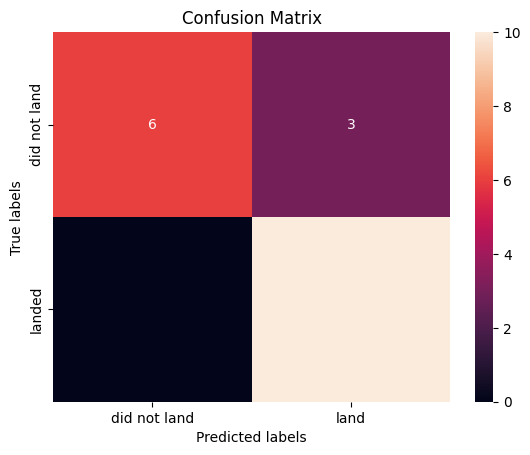

In [28]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


### 2. Support Vector Machine

Create a  GridSearchCV object and fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [29]:
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [30]:
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([1.0000...00000000e+03]), 'gamma': array([1.0000...00000000e+03]), 'kernel': ('linear', ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score

In [31]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(0.001), 'gamma': np.float64(1.0), 'kernel': 'poly'}
accuracy : 0.9053571428571429


Calculate the accuracy on the test data


In [32]:
svm_cv.score(X_test, Y_test)

0.8421052631578947

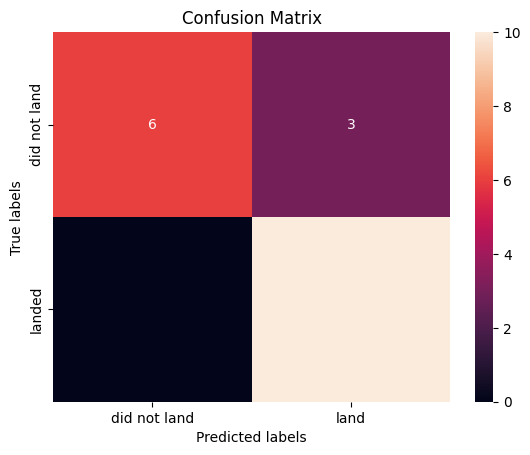

In [33]:
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

### 3. Decision Tree Classifier

Create a  GridSearchCV object and fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [34]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['auto', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()

In [35]:
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'max_features': ['auto', 'sqrt'], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and par

In [36]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
accuracy : 0.9178571428571429


Calculate the accuracy of `tree_cv` on the test data


In [37]:
tree_cv.score(X_test, Y_test)

0.7368421052631579

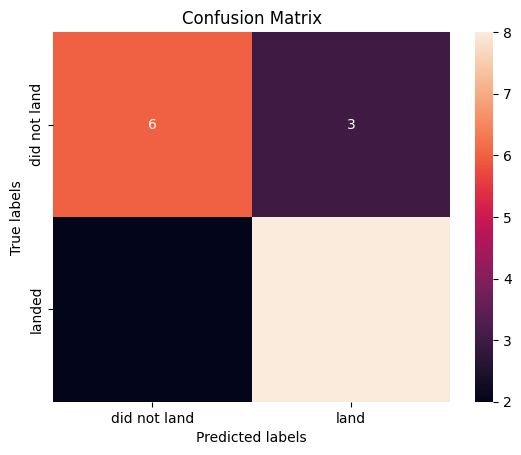

In [38]:
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

### 4. K-Nearest Neighbours

Create a  GridSearchCV object and fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [39]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [40]:
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'algorithm': ['auto', 'ball_tree', ...], 'n_neighbors': [1, 2, ...], 'p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [41]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 1, 'p': 1}
accuracy : 0.9053571428571429


Calculate the accuracy of `knn_cv` on the test data


In [42]:
knn_cv.score(X_test, Y_test)

0.7894736842105263

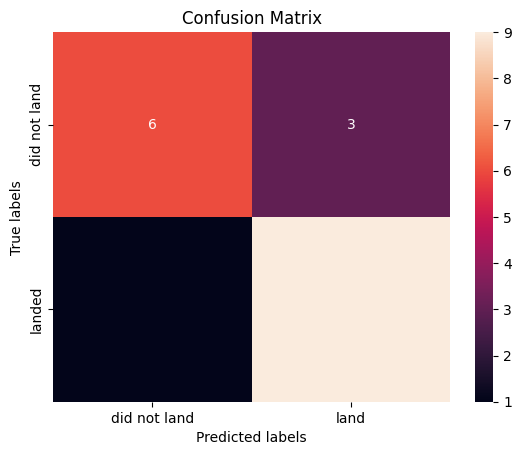

In [43]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

### Find the method that performs best


In [44]:
# Print the best score for each model
print("Logistic Regression best score: ", logreg_cv.score(X_test, Y_test))
print("SVM best score: ", svm_cv.score(X_test, Y_test))
print("Decision Tree best score: ", tree_cv.score(X_test, Y_test))
print("KNN best score: ", knn_cv.score(X_test, Y_test))


Logistic Regression best score:  0.8421052631578947
SVM best score:  0.8421052631578947
Decision Tree best score:  0.7368421052631579
KNN best score:  0.7894736842105263


**Best model: Support Vector Machine (SVM) or Logistic Regression**

**Reasoning**:
This is because these models have the lowest number of False Positives, making the model more robust to predictions. A lower False Positive rate is critical in scenarios where incorrectly predicting a positive outcome (e.g., launch success when it actually fails) has significant consequences. Therefore, these models are more robust and reliable for accurate classification under the current dataset.

**Recommendations for Improvement**: As more launch data becomes available in the future, the dataset will become larger and more representative, allowing the models to better learn complex patterns. This would improve accuracy, generalizability, and robustness of predictions.

-----

## Stakeholder-focused Conclusion

Now, we use the model to make a stakeholder-focused, business-impact-driven project by defining a stakeholder, a problem, and a solution with recommendations.

**Stakeholder**: Satellite Deployment Manager / Satellite Customer (e.g., a telecom company or satellite startup)

**Problem Statement**: Satellite companies need to choose between SpaceX and other launch providers. However, the cost advantage of SpaceX is only realized if the Falcon 9 first stage successfully lands (and is reused). Predicting this in advance can help customers assess risk and negotiate contracts.

In [45]:
# Model and scaler are already trained above — no need to redo
# Just confirm the model to use for prediction
model = logreg_cv


In [46]:
def prepare_input(input_dict, full_feature_columns, scaler, categorical_cols):
    df = pd.DataFrame([input_dict])
    df = pd.get_dummies(df)
    df = df.reindex(columns=full_feature_columns, fill_value=0)
    df = df.fillna(0)
    df_scaled = scaler.transform(df)
    return df_scaled


def predict_landing_success(model, input_dict, full_feature_columns, scaler, categorical_cols):
    """
    Predicts probability of first stage landing success and estimates launch cost.

    Parameters:
        - model: trained classification model (e.g., logistic regression)
        - input_dict: dictionary with launch configuration
        - full_feature_columns: list of feature names after get_dummies (from training)
        - scaler: StandardScaler object used during training
        - categorical_cols: list of categorical column names to one-hot encode

    Returns:
        - landing_probability (float)
        - expected_cost (float)
        - risk_level (str)
    """
    X_input = prepare_input(input_dict, full_feature_columns, scaler, categorical_cols)
    prob = model.predict_proba(X_input)[0][1]

    reused_cost = 62e6
    full_cost = 165e6
    expected_cost = prob * reused_cost + (1 - prob) * full_cost

    if prob >= 0.85:
        risk = "Low"
    elif prob >= 0.65:
        risk = "Medium"
    else:
        risk = "High"

    return prob, expected_cost, risk


In [47]:
full_feature_columns = X_imputed.columns.tolist()

categorical_cols = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']

# Define a sample input
new_launch = {
    'FlightNumber': 100,
    'PayloadMass': 5500.0,
    'Orbit': 'GTO',
    'LaunchSite': 'CCSFS SLC 40',
    'Flights': 3,
    'GridFins': True,
    'Reused': False,
    'Legs': True,
    'LandingPad': 'LZ-1',
    'Block': 5.0,
    'ReusedCount': 4.0,
    'Serial': 'B1049'
}

# Predict
prob, cost, risk = predict_landing_success(model, new_launch, full_feature_columns, scaler, categorical_cols)

# Show result
print(f"Landing Probability: {prob:.2%}")
print(f"Expected Launch Cost: ${cost:,.0f}")
print(f"Risk Level: {risk}")


Landing Probability: 0.00%
Expected Launch Cost: $165,000,000
Risk Level: High


In [48]:
import pickle
pickle.dump(logreg_cv, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(imputer, open("imputer.pkl", "wb"))
pickle.dump(full_feature_columns, open("columns.pkl", "wb"))

## Strategic Recommendation to the Stakeholder

Based on predicted landing success rates, satellite customers can strategically plan launch options and budgets:
1. For missions with high predicted success (>85%), choose SpaceX to save up to 40% in launch costs.
2. For lower success probabilities (<70%), either:
    * Negotiate lower launch prices with SpaceX due to risk
    * Purchase additional insurance
    * Choose a competitor for mission-critical launches